# Task (a) — Simulating tracks and detector hits in 2D

A Monte-Carlo simulator for a simplified particle detector.

## The physics
* No magnetic field, and every particle starts at the origin $(0,0)$.
* Forcing a line through the origin removes one of its two parameters; what
  remains is the **direction**, so a track is a **ray** with a single parameter,
  its azimuthal angle $\phi \in [0, 2\pi)$:
$$ (x, y) = (r\cos\phi,\; r\sin\phi), \qquad r \ge 0. $$

## The detector
Five concentric circles, equally spaced radii $R\in\{2,4,6,8,10\}$.

## Where a track hits a circle
Every track passes through the origin — the common centre of all circles — so
the crossing with a circle of radius $R$ is just $(R\cos\phi,\,R\sin\phi)$, no
line-circle quadratic needed. Each track leaves one hit per circle: a 3-track
event has $3\times5=15$ hits.


### Setup: make the `src` package importable
Walks up from the working directory to find the project root, so this works whether the kernel starts at the repo root (VS Code) or in `notebooks/` (plain Jupyter).

In [1]:
import sys, os

def add_project_root_to_path():
    """Put the project root (folder containing 'src/') on sys.path,
    regardless of the kernel's working directory."""
    here = os.path.abspath(os.getcwd())
    while here != os.path.dirname(here):
        if os.path.isdir(os.path.join(here, "src")):
            if here not in sys.path:
                sys.path.insert(0, here)
            return here
        here = os.path.dirname(here)
    raise RuntimeError("Project root containing 'src/' not found.")

add_project_root_to_path()

import numpy as np
import matplotlib.pyplot as plt
from src.simulator import (detector_radii, sample_track_angles, track_hits,
                           simulate_event, simulate_events)
from src.plotting import plot_event, draw_detector

RADII = detector_radii(5, 2.0)
RADII

array([ 2.,  4.,  6.,  8., 10.])

## 1. One event — the hit table
One row per hit; `track_id` is the ground-truth label the network predicts in task (d).

In [2]:
event = simulate_event(0, n_tracks=3, rng=np.random.default_rng(0))
event

,event_id,track_id,layer,x,y,phi
0,0,0,0,-1.304033,-1.516410,4.002148
1,0,0,1,-2.608065,-3.032820,4.002148
2,0,0,2,-3.912098,-4.549230,4.002148
3,0,0,3,-5.216130,-6.065640,4.002148
4,0,0,4,-6.520163,-7.582050,4.002148
5,0,1,0,-0.248007,1.984564,1.695120
6,0,1,1,-0.496014,3.969127,1.695120
7,0,1,2,-0.744021,5.953691,1.695120
8,0,1,3,-0.992029,7.938254,1.695120
9,0,1,4,-1.240036,9.922818,1.695120


## 2. Correctness check
Every hit must sit exactly on its circle.

In [3]:
r = np.hypot(event["x"], event["y"])
expected = RADII[event["layer"].to_numpy()]
assert np.allclose(r, expected)
print("max deviation:", np.abs(r - expected).max(), "-> all hits lie on their circle")

max deviation: 8.881784197001252e-16 -> all hits lie on their circle


## 3. Visualise one event

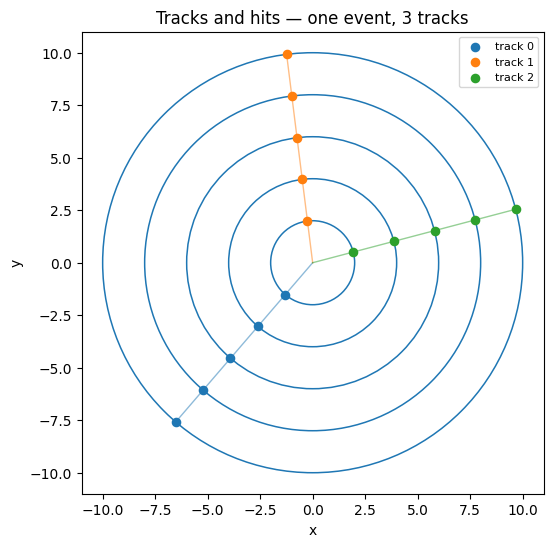

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))
plot_event(event, ax=ax, radii=RADII)
ax.set_title("Tracks and hits — one event, 3 tracks")
plt.show()

## 4. Four independent events
Same rules, different random draws — the Monte-Carlo idea.

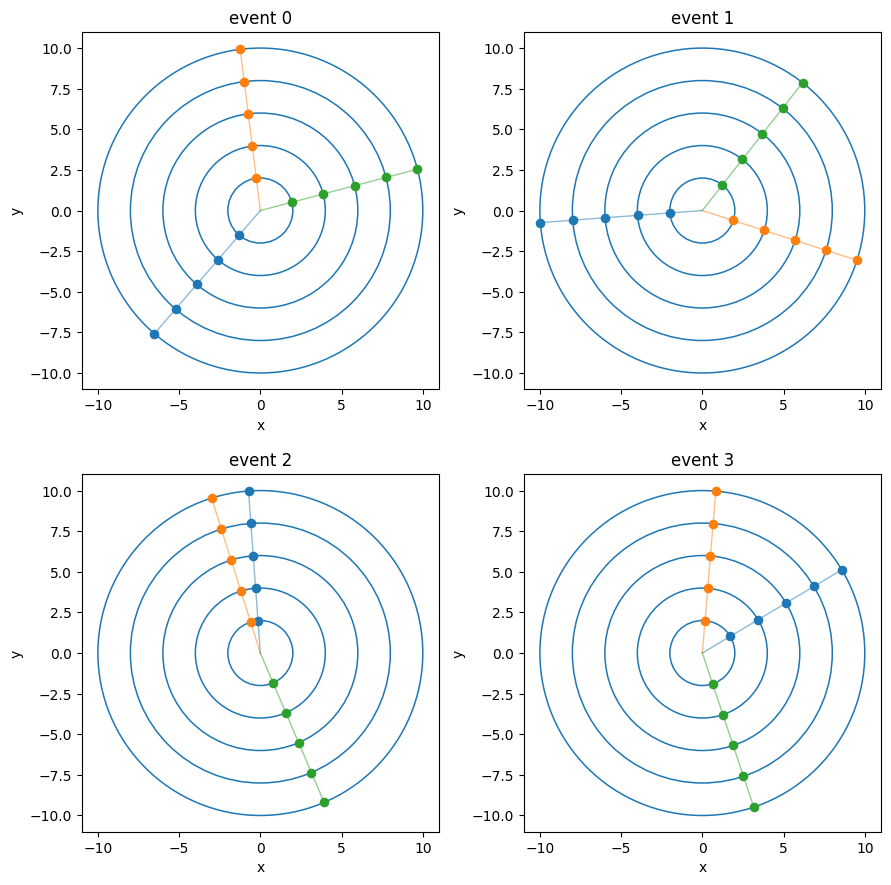

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(9, 9))
for i, ax in enumerate(axes.ravel()):
    ev = simulate_event(i, n_tracks=3, rng=np.random.default_rng(i))
    plot_event(ev, ax=ax, radii=RADII, legend=False)
    ax.set_title(f"event {i}")
fig.tight_layout(); plt.show()

## 5. Verification across many tracks
Hit distance vs layer for 200 events — every point on a nominal radius.

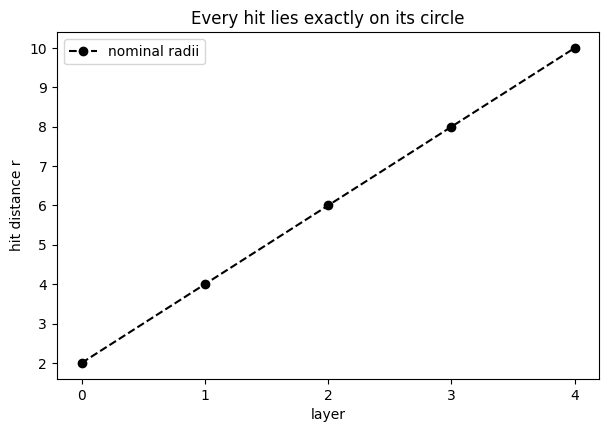

In [6]:
df = simulate_events(200, seed=1, n_tracks=3)
df["r"] = np.hypot(df["x"], df["y"])
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(df["layer"], df["r"], s=8, alpha=0.2, color="tab:purple")
ax.plot(range(5), RADII, "k--", marker="o", label="nominal radii")
ax.set_xlabel("layer"); ax.set_ylabel("hit distance r"); ax.set_xticks(range(5))
ax.set_title("Every hit lies exactly on its circle"); ax.legend(); plt.show()

## 6. The Monte-Carlo is unbiased\nSampled $\phi$ is uniform on $[0, 2\pi)$ — isotropic emission. (Preview of task c.)

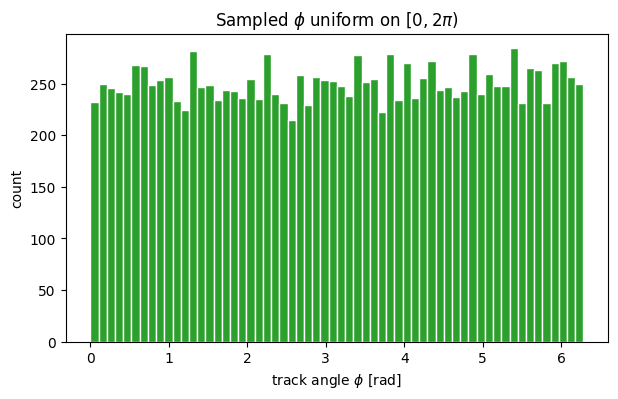

In [7]:
df_big = simulate_events(5000, seed=2, n_tracks=3)
phi_per_track = df_big.groupby(["event_id", "track_id"])["phi"].first()
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(phi_per_track, bins=60, color="tab:green", edgecolor="white")
ax.set_xlabel(r"track angle $\phi$ [rad]"); ax.set_ylabel("count")
ax.set_title(r"Sampled $\phi$ uniform on $[0, 2\pi)$"); plt.show()

## 7. All hits populate the rings

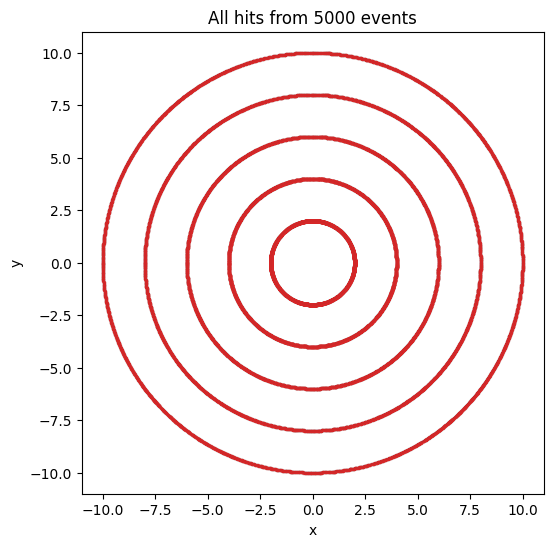

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))
draw_detector(ax, RADII)
ax.scatter(df_big["x"], df_big["y"], s=2, alpha=0.15, color="tab:red")
lim = RADII.max()*1.1
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("All hits from 5000 events"); plt.show()

## Summary
* A track = one angle $\phi$; a hit = $(R\cos\phi, R\sin\phi)$.
* Output is a tidy table `event_id, track_id, layer, x, y, phi` matching the
  provided data, reused directly by tasks (c) and (d).
* `track_id` is the supervised label for the hit-to-track network.

**Next (task b):** record each hit with 95% probability and add Gaussian
position smearing; then generate 10,000 events with 10 tracks.